[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/sibbirhossain/finguard-xai/blob/main/notebooks/01_problem_and_motivation.ipynb)

# 01 · The Problem: Coordinated Payment Fraud in the U.S.

**Question this notebook answers:** *why do conventional, transaction-by-transaction fraud models miss organized fraud, and why is that an important problem for the United States?*

### Scale of the problem (official U.S. sources)
| Source | Figure |
|---|---|
| Federal Trade Commission, Consumer Sentinel (Mar 2025) | Consumers reported losing **$12.5 billion** to fraud in 2024, up 25% from 2023 |
| FBI Internet Crime Complaint Center, 2024 report | **$16.6 billion** in reported cybercrime losses in 2024, up 33%; cyber-enabled fraud accounted for $13.7 billion |
| U.S. GAO, GAO-24-105833 (Apr 2024) | The federal government loses an estimated **$233–$521 billion per year** to fraud |

These figures are *reported* losses. The FTC and FBI both note that most fraud goes unreported.

In [1]:
# --- Setup: works in Google Colab and inside a local clone ---
import os, sys, subprocess, warnings
warnings.filterwarnings("ignore")
if os.path.exists("../src/models"):
    os.chdir("..")
elif not os.path.exists("src/models"):
    if not os.path.exists("finguard-xai"):
        subprocess.run(["git", "clone", "-q", "https://github.com/sibbirhossain/finguard-xai.git"], check=True)
    os.chdir("finguard-xai")
try:
    import torch_geometric  # noqa: F401
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "torch_geometric"], check=True)
sys.path.insert(0, os.getcwd())
import warnings; warnings.filterwarnings("ignore")
import json, numpy as np, matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
print("ready:", os.getcwd())

ready: /home/claude/finguard-xai


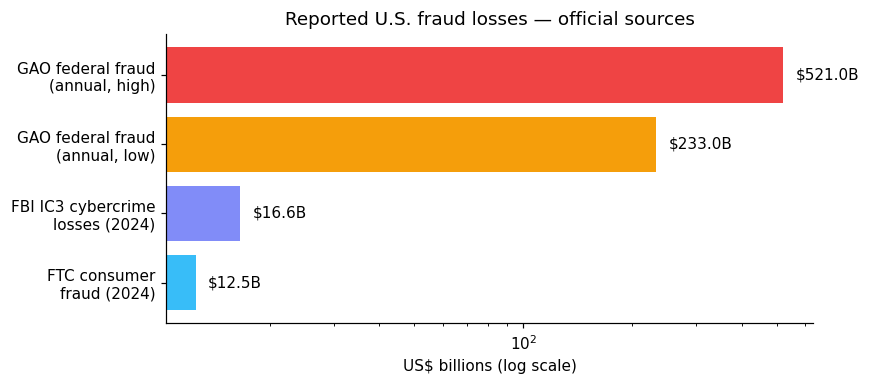

In [2]:
sources = ["FTC consumer\nfraud (2024)", "FBI IC3 cybercrime\nlosses (2024)", "GAO federal fraud\n(annual, low)", "GAO federal fraud\n(annual, high)"]
billions = [12.5, 16.6, 233, 521]
fig, ax = plt.subplots(figsize=(8, 3.6))
bars = ax.barh(sources, billions, color=["#38bdf8", "#818cf8", "#f59e0b", "#ef4444"])
ax.set_xscale("log"); ax.set_xlabel("US$ billions (log scale)")
for b, v in zip(bars, billions):
    ax.text(v * 1.08, b.get_y() + b.get_height() / 2, f"${v:,.1f}B", va="center")
ax.set_title("Reported U.S. fraud losses — official sources"); plt.tight_layout(); plt.show()

### Why individual transactions are not enough
Organized fraud rings spread activity across many cards. They route it through shared (often compromised) devices and IP addresses, and they cash out at a few colluding merchants. **Each individual transaction can look ordinary.** The signal lives in the *relationships* between entities.

The cells below use the project's synthetic generator, which contains no real personal data, to make this concrete.

{'normal': 20000, 'ring': 572, 'ato': 205} fraud rate = 3.74%


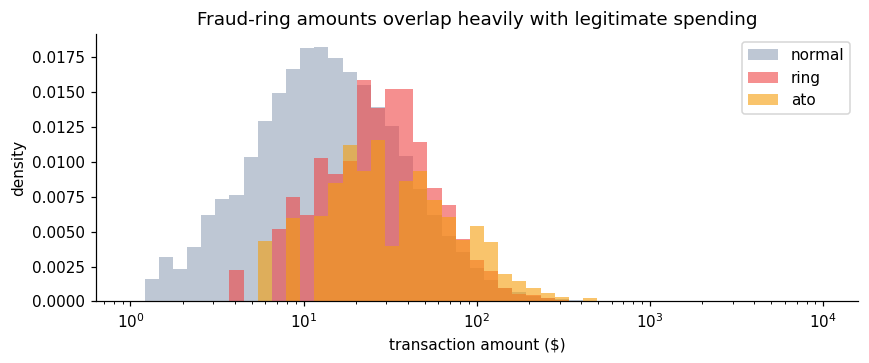

In [3]:
from src.api.stream_simulator import generate_transactions
rows = generate_transactions(n_normal=20000, n_rings=20, n_ato=100, seed=0)
amt = {s: np.array([r["amount"] for r in rows if r["scenario"] == s]) for s in ("normal", "ring", "ato")}
print({s: len(v) for s, v in amt.items()}, f"fraud rate = {np.mean([r['label'] for r in rows]):.2%}")
fig, ax = plt.subplots(figsize=(8, 3.4))
bins = np.logspace(0, 4, 50)
for s, c in (("normal", "#94a3b8"), ("ring", "#ef4444"), ("ato", "#f59e0b")):
    ax.hist(amt[s], bins=bins, alpha=.6, density=True, label=s, color=c)
ax.set_xscale("log"); ax.set_xlabel("transaction amount ($)"); ax.set_ylabel("density"); ax.legend()
ax.set_title("Fraud-ring amounts overlap heavily with legitimate spending"); plt.tight_layout(); plt.show()

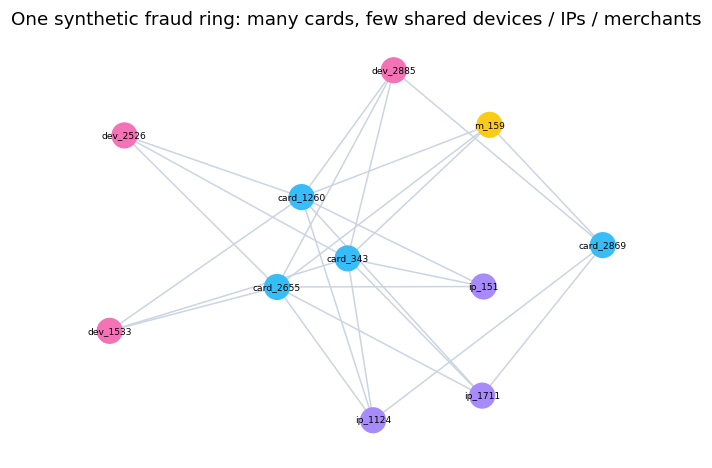

In [4]:
import networkx as nx
ring = [r for r in rows if r["scenario"] == "ring"]
first = ring[0]; t0 = first["timestamp"]
members = [r for r in ring if abs(r["timestamp"] - t0) < 48 * 3600 and r["merchant_id"] in {x["merchant_id"] for x in ring[:5]}][:40]
G = nx.Graph()
colors = {"card": "#38bdf8", "dev": "#f472b6", "m": "#facc15", "ip": "#a78bfa"}
for r in members:
    for a, b in (("card_id", "device_id"), ("card_id", "merchant_id"), ("card_id", "ip_id")):
        G.add_edge(r[a], r[b])
node_col = [colors[n.split("_")[0]] for n in G.nodes]
plt.figure(figsize=(7, 5))
nx.draw_networkx(G, nx.spring_layout(G, seed=3), node_color=node_col, node_size=260, font_size=6, edge_color="#cbd5e1")
plt.title("One synthetic fraud ring: many cards, few shared devices / IPs / merchants"); plt.axis("off"); plt.show()

### What this project contributes
1. **A streaming graph of payment entities** (card, device, merchant, IP) that is updated with every event and queried *point-in-time*, so no future information leaks into a prediction.
2. **A temporal graph neural network** that learns from those relationships, measured against a strong non-graph baseline.
3. **Dual-channel alerting.** A supervised channel handles known fraud patterns, and a separate novelty channel with a fixed false-positive budget catches fraud types the model has *never seen* (notebook 04).
4. **An explanation for every alert** that analysts can audit (notebook 03).
5. **Real-time performance**, measured in milliseconds per transaction (notebook 05).

Continue with **02 · Solution & Benchmark**.